In [127]:
import numpy as np
import pandas as pd

df=pd.read_csv('product_sales.csv')

In [128]:
# EDA (Numerical Data)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductID      100 non-null    object 
 1   Brand          100 non-null    object 
 2   ProductType    100 non-null    object 
 3   StoreLocation  100 non-null    object 
 4   Price          100 non-null    float64
 5   QuantitySold   100 non-null    int64  
 6   Condition      100 non-null    object 
 7   DateSold       100 non-null    object 
 8   Rating         100 non-null    object 
 9   Review         100 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 7.9+ KB


,Price,QuantitySold
count,100.000000,100.00000
mean,48.576100,50.85000
std,20.207237,30.64801
min,3.640000,0.00000
25%,35.340000,23.00000
50%,46.925000,47.50000
75%,60.145000,80.25000
max,111.220000,99.00000


In [129]:
df.head()

,ProductID,Brand,ProductType,StoreLocation,Price,QuantitySold,Condition,DateSold,Rating,Review
0,P0000,Soylent,Toys,New York,61.34,91,New,2024-06-03,5,Excellent quality!
1,P0001,Initech,Electronics,Houston,46.71,68,New,2024-05-24,4,Value for money
2,P0002,Umbrella,Electronics,New York,47.14,46,New,2024-06-09,⭐,Great product!
3,P0003,Initech,Electronics,Miami,11.31,93,New,2024-06-05,three,Highly recommended
4,P0004,Initech,Electronics,New York,53.01,61,New,2024-05-20,1,Perfect gift 🎁


In [130]:
# Check for missing values
df.isna().sum()

# Data cleaning
def convert_rating(rating) -> int | None:
    rating=str(rating).strip()
    if rating.isdigit():
        return int(rating)

    stars={'⭐', '★'}
    star_count=sum(1 for c in rating if c in stars)

    return star_count
    
df=df.drop(columns=['ProductID', 'Review'])
df['Rating']=df['Rating'].apply(convert_rating)
df['Price']=df['Price'].round(2)
    
# Force Display
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

# for col in df.columns:
#     print(f"\n{col} ➤ Unique values:")
#     print(df[col].dropna().unique())

In [131]:
# Check for outliers [IQR]
# Conditions:
# min < lower bound
# max > upper bound
Q3=60.145
Q1=35.34
IQR=Q3-Q1

lower_bound=round(Q1-1.5*IQR)
upper_bound=round(Q3+1.5*IQR)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -2
Upper Bound: 97


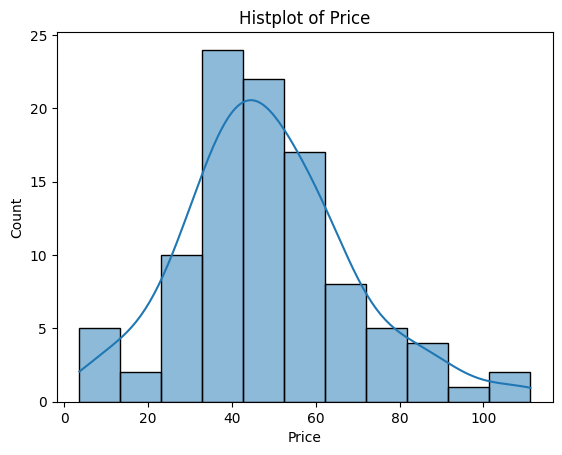

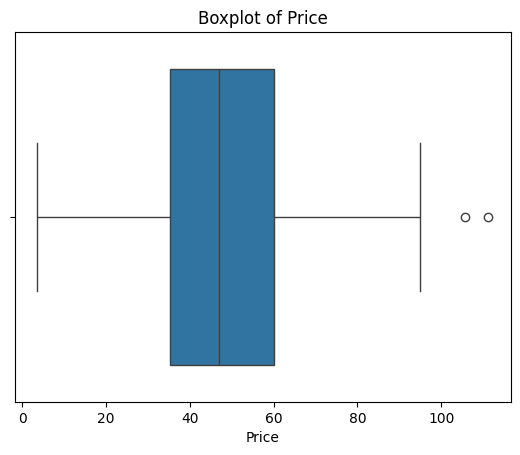

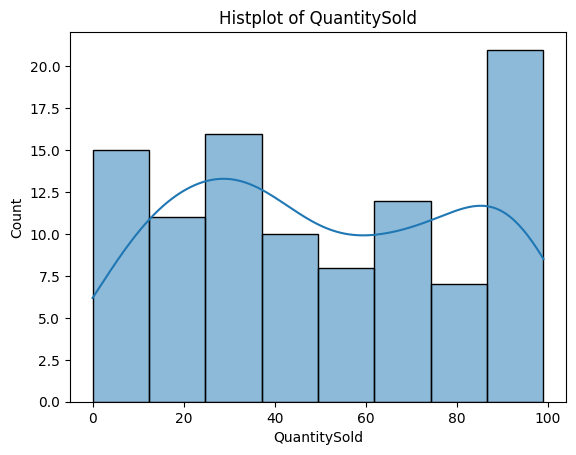

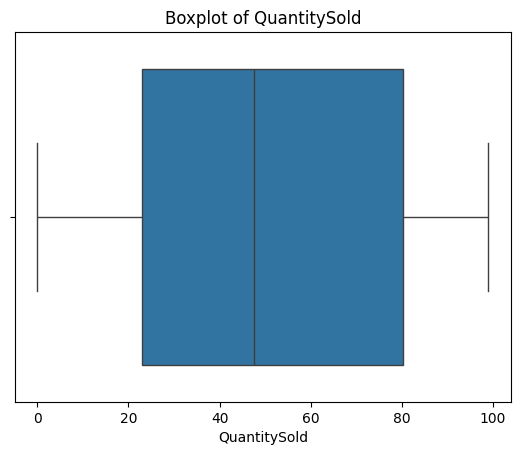

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize numeric variables
# Boxplot - detects outliers
# Histplot - distribution

sns.histplot(df['Price'], kde=True)
plt.title('Histplot of Price')
plt.show()

sns.boxplot(x=df['Price'])
plt.title('Boxplot of Price')
plt.show()

sns.histplot(df['QuantitySold'], kde=True)
plt.title('Histplot of QuantitySold')
plt.show()
        
sns.boxplot(x=df['QuantitySold'])
plt.title('Boxplot of QuantitySold')
plt.show()

# Rating (dirty)

In [133]:
# Outliers
# 1. Show outliers
outliers=df[df['Price'] > upper_bound]
print(outliers['Price'])

# 2. Decide what to do with the outliers, if any[Remove(Errors), Cap(Clip), Log Transform(Right-Skewed)]
df['Price_capped']=df['Price'].clip(upper=upper_bound)

13    111.22
26    105.68
Name: Price, dtype: float64


In [134]:
from scipy.stats import skew

# Distribution
# 1. Check skewness
skewness_price=skew(df['Price'])
skewness_quantity_sold=skew(df['QuantitySold'])
print(f"Skewness(Price): {skewness_price}")
print(f"Skewness(QuantitySold): {skewness_quantity_sold}")

# 2. Apply log/sqrt transform if skewed
# df['_log'] = np.log1p(df[''])
# df['_sqrt'] = np.sqrt(df[''])

Skewness(Price): 0.5177307163032288
Skewness(QuantitySold): 0.06307206184888946


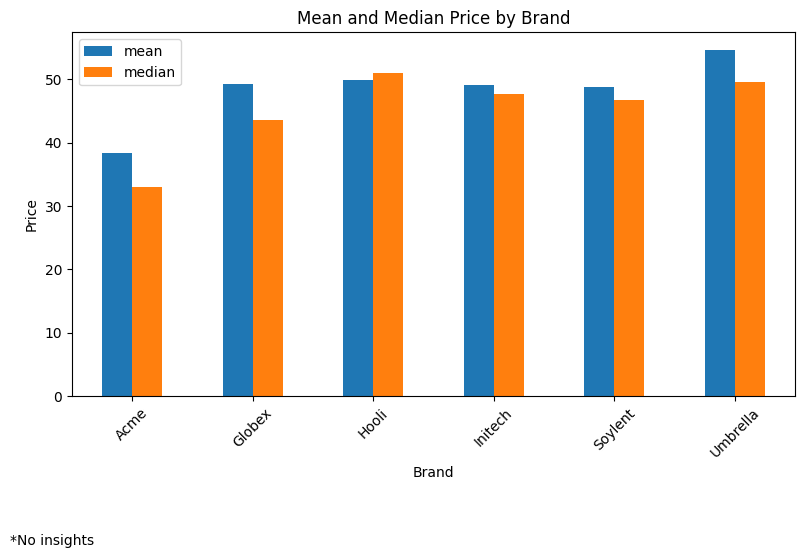

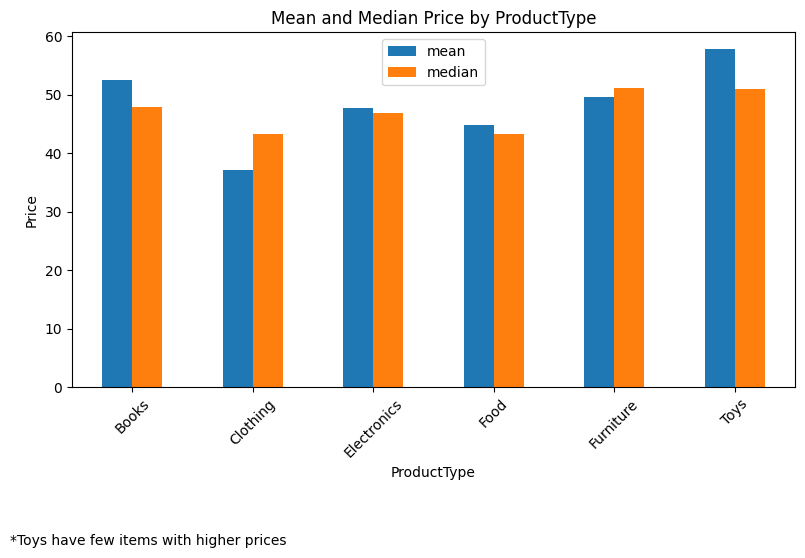

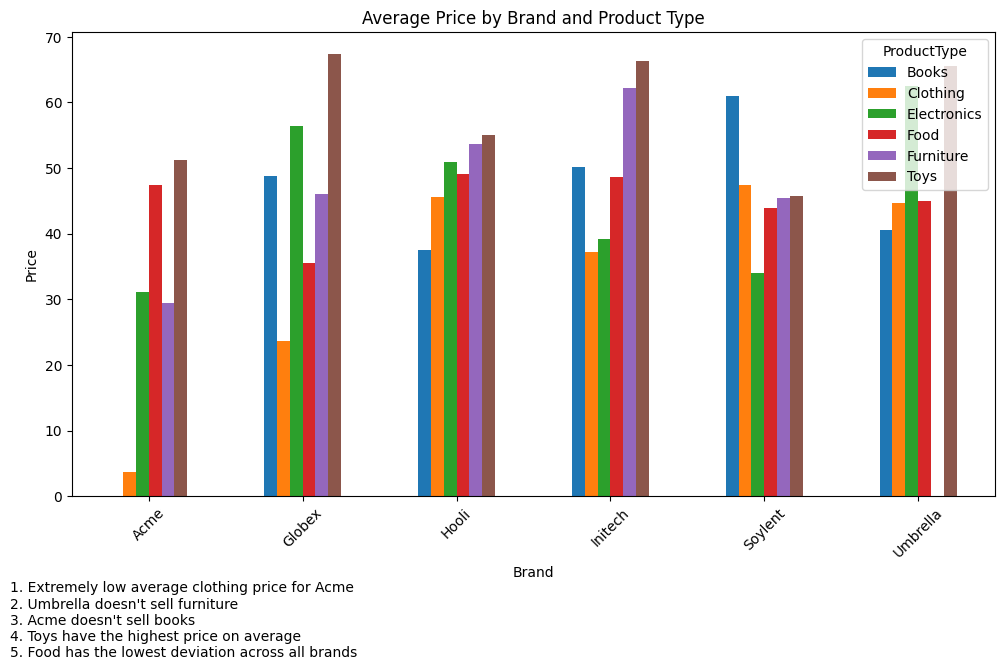

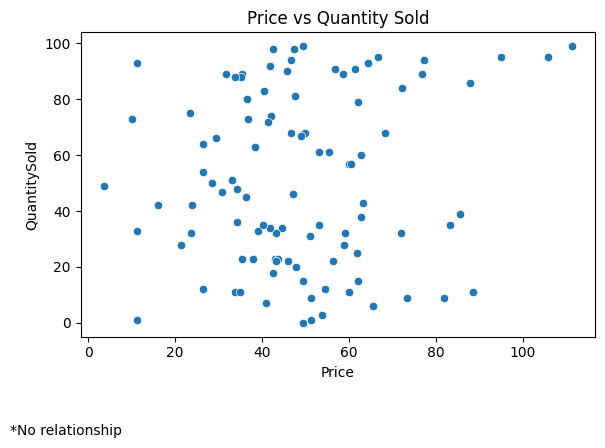

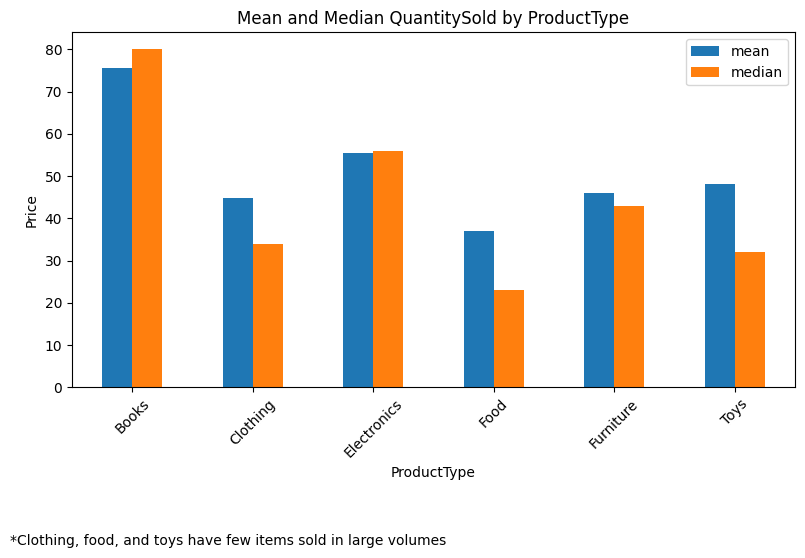

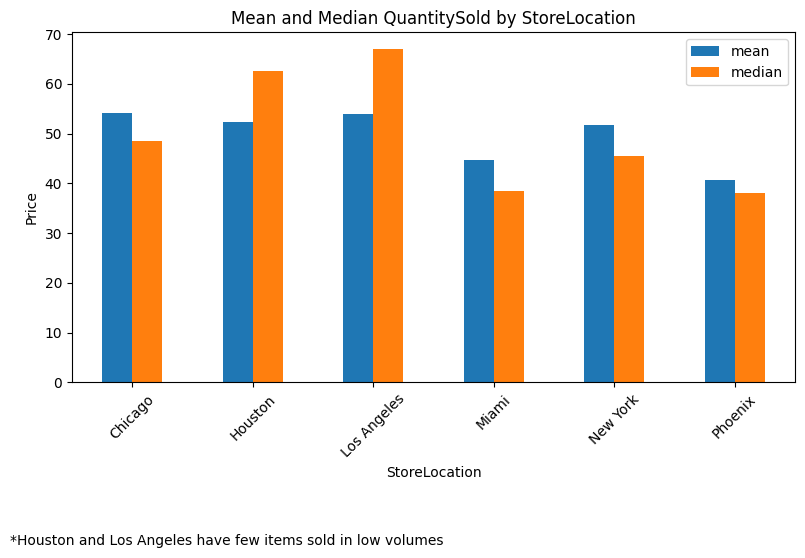

In [161]:
# EDA (Categorical Data)
# Nominal categories
# 1-2. Count, Visualize
categorical_cols = ['Brand', 'ProductType', 'StoreLocation']

# for col in categorical_cols:
#     print(f"{col} (Unique: {df[col].nunique()}):\n{df[col].value_counts()}\n")
    
#     plt.figure(figsize=(6, 4))
#     sns.countplot(x=col, data=df, order=df[col].value_counts().index)
#     plt.title(f'Countplot of {col}')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

# 2. Group (Barplot[C-N], Scatterplot[N-N])
# Brand-Price
brand_to_price=df.groupby('Brand')['Price'].agg(['mean','median'])
brand_to_price.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median Price by Brand')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*No insights",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# ProductType-Price
product_type_to_price=df.groupby('ProductType')['Price'].agg(['mean','median'])
product_type_to_price.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median Price by ProductType')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Toys have few items with higher prices",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# Brand,ProductType-Price
brand_product_price=df.groupby(['Brand', 'ProductType'])['Price'].mean().unstack()
brand_product_price.plot(kind='bar', figsize=(10, 6))
plt.title('Average Price by Brand and Product Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "1. Extremely low average clothing price for Acme\n"
    "2. Umbrella doesn't sell furniture\n"
    "3. Acme doesn't sell books\n"
    "4. Toys have the highest price on average\n"
    "5. Food has the lowest deviation across all brands",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# Price-QuantitySold
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Price', y='QuantitySold', data=df)
plt.title('Price vs Quantity Sold')
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*No relationship",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# ProductType-QuantitySold
product_type_to_quantity_sold=df.groupby('ProductType')['QuantitySold'].agg(['mean','median'])
product_type_to_quantity_sold.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median QuantitySold by ProductType')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Clothing, food, and toys have few items sold in large volumes",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# StoreLocation-QuantitySold
store_location_to_quantity_sold=df.groupby('StoreLocation')['QuantitySold'].agg(['mean','median'])
store_location_to_quantity_sold.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median QuantitySold by StoreLocation')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Houston and Los Angeles have few items sold in low volumes",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# Ordinal categories
# Condition, Rating

# One-hot Encoding
# df=pd.get_dummies(df, columns=['Brand'], drop_first=True)
# df=pd.get_dummies(df, columns=['ProductType'], drop_first=True)
# df=pd.get_dummies(df, columns=['StoreLocation'], drop_first=True)
# df['Condition']=df['Condition'].map({
#     'Used': 0,
#     'Refurbished': 1,
#     'New': 2
# })